In [1]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y = True, as_frame = True)

In [2]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [3]:
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [5]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((309, 10), (133, 10), (309,), (133,))

In [6]:
from sklearn.linear_model import ElasticNet

## GridSearchCV

In [7]:
from sklearn.model_selection import GridSearchCV

In [14]:
param_grid = {
    'alpha' : [0.01, 0.1, 1],
    'l1_ratio' : [0.2, 0.5, 0.8]
}    

In [41]:
grid_search = GridSearchCV(estimator = ElasticNet(),
                           param_grid = param_grid,
                           cv = 5,
                           scoring = ['r2','neg_mean_squared_error'],
                           refit = 'r2',
                           n_jobs = -1)

grid_search

GridSearchCV(cv=5, estimator=ElasticNet(), n_jobs=-1,
             param_grid={'alpha': [0.01, 0.1, 1], 'l1_ratio': [0.2, 0.5, 0.8]},
             refit='r2', scoring=['r2', 'neg_mean_squared_error'])

In [42]:
%%time
grid_search.fit(X_train, y_train)

CPU times: user 48.6 ms, sys: 60.1 ms, total: 109 ms
Wall time: 150 ms


GridSearchCV(cv=5, estimator=ElasticNet(), n_jobs=-1,
             param_grid={'alpha': [0.01, 0.1, 1], 'l1_ratio': [0.2, 0.5, 0.8]},
             refit='r2', scoring=['r2', 'neg_mean_squared_error'])

In [44]:
grid_search.best_score_

0.41384456556589216

In [45]:
grid_search.best_params_

{'alpha': 0.01, 'l1_ratio': 0.8}

In [46]:
grid_search.best_estimator_

ElasticNet(alpha=0.01, l1_ratio=0.8)

In [50]:
import pandas as pd
pd.options.display.max_columns = None

In [53]:
pd.DataFrame(grid_search.cv_results_).sort_values(by="rank_test_r2").head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_l1_ratio,params,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,split4_test_r2,mean_test_r2,std_test_r2,rank_test_r2,split0_test_neg_mean_squared_error,split1_test_neg_mean_squared_error,split2_test_neg_mean_squared_error,split3_test_neg_mean_squared_error,split4_test_neg_mean_squared_error,mean_test_neg_mean_squared_error,std_test_neg_mean_squared_error,rank_test_neg_mean_squared_error
2,0.003131,0.000913,0.002262,0.001729,0.01,0.8,"{'alpha': 0.01, 'l1_ratio': 0.8}",0.417600,0.502404,0.324758,0.385771,0.438690,0.413845,0.058649,1,-3943.256750,-3060.624504,-3674.367470,-3457.701480,-3001.643065,-3427.518654,358.834909,1
1,0.002288,0.000401,0.001363,0.000249,0.01,0.5,"{'alpha': 0.01, 'l1_ratio': 0.5}",0.348589,0.419625,0.277442,0.324732,0.355312,0.345140,0.046180,2,-4410.513130,-3569.778927,-3931.837387,-3801.306973,-3447.512490,-3832.189781,335.313991,2
0,0.006015,0.001122,0.001922,0.000198,0.01,0.2,"{'alpha': 0.01, 'l1_ratio': 0.2}",0.298777,0.356201,0.242227,0.273721,0.297650,0.293715,0.037407,3,-4747.777063,-3959.893469,-4123.460347,-4088.465316,-3755.865288,-4135.092297,332.325068,3


## RandomSearch

In [55]:
from sklearn.model_selection import RandomizedSearchCV

In [57]:
from scipy import stats

In [58]:
stats.norm()

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

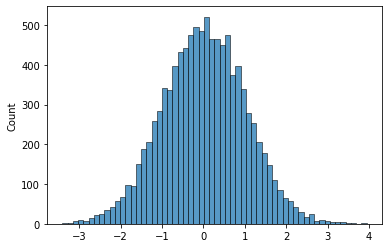

In [71]:
sns.histplot(stats.norm.rvs(size=10_000),kde = False);

In [72]:
stats.uniform()

In [77]:
stats.uniform.rvs()

0.4300674296119832

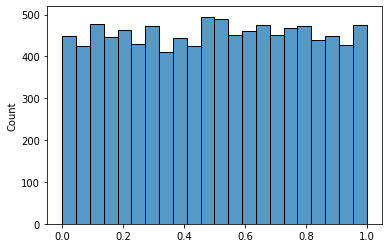

In [78]:
sns.histplot(stats.uniform.rvs(size=10_000),kde = False);

In [80]:
param_distributions = {
    'alpha': [0.001, 0.01, 0.1, 1],
    'l1_ratio' : stats.uniform(0,1)
    
    
}

In [82]:
random_search = RandomizedSearchCV(estimator = ElasticNet(),
                                   param_distributions = param_distributions,
                                   scoring = ['r2','neg_mean_squared_error'],
                                   refit = 'r2',
                                   cv = 5,
                                   n_jobs = -1,
                                   n_iter =20)

random_search

RandomizedSearchCV(cv=5, estimator=ElasticNet(), n_iter=20, n_jobs=-1,
                   param_distributions={'alpha': [0.001, 0.01, 0.1, 1],
                                        'l1_ratio': <scipy.stats._distn_infrastructure.rv_frozen object at 0x18dfba070>},
                   refit='r2', scoring=['r2', 'neg_mean_squared_error'])

In [83]:
%%time
random_search.fit(X_train, y_train)

CPU times: user 98.9 ms, sys: 134 ms, total: 233 ms
Wall time: 1.76 s


RandomizedSearchCV(cv=5, estimator=ElasticNet(), n_iter=20, n_jobs=-1,
                   param_distributions={'alpha': [0.001, 0.01, 0.1, 1],
                                        'l1_ratio': <scipy.stats._distn_infrastructure.rv_frozen object at 0x18dfba070>},
                   refit='r2', scoring=['r2', 'neg_mean_squared_error'])

In [84]:
random_search.best_score_

0.4479552276803596

In [85]:
random_search.best_params_

{'alpha': 0.001, 'l1_ratio': 0.6751051339298209}

In [86]:
random_search.best_estimator_

ElasticNet(alpha=0.001, l1_ratio=0.6751051339298209)

In [87]:
pd.DataFrame(random_search.cv_results_).sort_values(by="rank_test_r2").head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_l1_ratio,params,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,split4_test_r2,mean_test_r2,std_test_r2,rank_test_r2,split0_test_neg_mean_squared_error,split1_test_neg_mean_squared_error,split2_test_neg_mean_squared_error,split3_test_neg_mean_squared_error,split4_test_neg_mean_squared_error,mean_test_neg_mean_squared_error,std_test_neg_mean_squared_error,rank_test_neg_mean_squared_error
0,0.004674,0.002566,0.003098,0.001342,0.001,0.675105,"{'alpha': 0.001, 'l1_ratio': 0.6751051339298209}",0.458349,0.539639,0.361608,0.379714,0.500466,0.447955,0.068387,1,-3667.362043,-2831.597683,-3473.844393,-3491.794563,-2671.292448,-3227.178226,397.522518,1
1,0.002824,0.000284,0.002013,0.000898,0.001,0.574129,"{'alpha': 0.001, 'l1_ratio': 0.5741289685688414}",0.457130,0.539307,0.359184,0.385242,0.497786,0.447730,0.067417,2,-3675.617130,-2833.637085,-3487.032125,-3460.676483,-2685.623309,-3228.517226,392.757006,2
14,0.001500,0.000079,0.001044,0.000095,0.01,0.98006,"{'alpha': 0.01, 'l1_ratio': 0.9800596080201462}",0.458398,0.540830,0.362149,0.371589,0.501557,0.446905,0.070423,3,-3667.031242,-2824.269638,-3470.899149,-3537.534087,-2665.457327,-3233.038289,406.665789,3
